# 🛒 Quick Commerce (Q-Commerce) Platform Analysis
### Competitive Intelligence Across 8 Indian Delivery Platforms

---

**Author:** (my name)  
**Dataset:** 1,000,000 synthetic orders across 8 Q-Commerce platforms (Swiggy Instamart, Blinkit, Zepto, Big Basket, Flipkart Minutes, Amazon Now, Dunzo, Jio Mart)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly · SciPy · Scikit-learn

---

## 🎯 Business Context

Quick Commerce is a hyper-competitive segment of e-commerce focused on ultra-fast delivery (typically under 30 minutes). In India, platforms like Blinkit, Zepto, and Swiggy Instamart are locked in intense competition on three dimensions: **revenue**, **delivery speed**, and **customer satisfaction**.

This analysis answers four core business questions:

| # | Question |
|---|----------|
| 1 | Which platforms generate the most revenue, and why? |
| 2 | Who are the customers, and what are they buying? |
| 3 | Which platforms are operationally fastest and most consistent? |
| 4 | Does offering discounts actually increase order value? |

---

## 📋 Key Findings (Executive Summary)

> 💰 **Swiggy Instamart leads in total revenue** (~₹71.5M), but the gap between all platforms is quite narrow — less than 24% separates #1 from #8, indicating a  competitive market.

> ⚡ **Zepto dominates on delivery speed** — averaging just 0.839km/min vs. Jio Mart's 0.340km/min. Speed is Zepto's clear differentiator.

> 🧑‍🤝‍🧑 **The 21–50 age band drives ~71% of all orders** across every platform. Teens (11–20) represent only 7.2%, suggesting Q-Commerce skews toward working adults.

> 🏙️ **Gurgaon and Noida are the top revenue cities**, but all 10 major cities are within 17% of each other — indicating geographically even demand.

> 💸 **Discounted orders have 42% higher average order value** (₹677 vs. ₹477). Discounts likely attract higher-basket customers, not just more orders.

> 📦 **High-value outlier orders (bulk buyers) show a strong inverse relationship** between order value and delivery time — suggesting premium/bulk orders receive faster service.


---
## 1. Environment Setup & Data Loading

In [1]:
# ───Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import math
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ───Global Plot Style ──────────────────────────────────────────────────────────
sns.set_theme(style = 'whitegrid', palette = 'bright', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# ───Currency formatter ──────────────────────────────────────────────────────────
rupee_fmt = ticker.FuncFormatter(lambda x, _: f'₹{int(x):,}')

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
df_raw = pd.read_csv(r'Project15_Q-Commerce Data Analysis/quick_commerce_data_raw.csv')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 1,000,000 rows x 13 columns


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.6600,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8


---
## 2. Data Quality Assesment
Before cleaning, I audited the data set to understand its structure and completeness.

In [3]:
# Schema and Data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [4]:
# Statistical profile of numeric columns
df_raw.describe(include = 'number').round(2)

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,965000.00,953000.00,1000000.00,895863.00
mean,1500000.50,38.47,571.64,16.45,7.75,10.00,3.04,0.40,3.75
std,288675.28,12.12,382.78,6.26,4.19,5.48,1.19,0.49,0.72
min,1000001.00,18.00,50.00,5.00,0.50,1.00,1.00,0.00,2.50
25%,1250000.75,28.00,287.84,12.37,4.13,5.00,2.00,0.00,3.10
50%,1500000.50,38.00,531.32,16.34,7.74,10.00,3.00,0.00,3.70
75%,1750000.25,49.00,796.18,20.20,11.38,15.00,4.00,1.00,4.40
max,2000000.00,59.00,13877.32,40.00,15.00,19.00,5.00,1.00,5.00


In [5]:
# Duplicate check
n_duplicates = df_raw.duplicated().sum()
print(f'Duplicated rows: {n_duplicates:,}')

Duplicated rows: 0


In [6]:
# Null value Audit
null_count = df_raw.isna().sum()
null_pct   = (null_count/len(df_raw)*100).round(2)

null_report = pd.DataFrame({
    'Null Count': null_count,
    '% Missing': null_pct,
    'Action': ''
})
null_report.loc['City',                    'Action'] = "Fill with 'Other' — unknown city, not missing data"
null_report.loc['Items_Count',             'Action'] = "Drop rows — cannot impute order size"
null_report.loc['Customer_Rating',         'Action'] = "Group-median impute by Company"
null_report.loc['Delivery_Partner_Rating', 'Action'] = "Group-mean impute by Company"

print('Missing Value Audit:')
null_report[null_report['Null Count'] > 0]

Missing Value Audit:


,Null Count,% Missing,Action
City,52000,5.20,"Fill with 'Other' — unknown city, not missing ..."
Items_Count,35000,3.50,Drop rows — cannot impute order size
Customer_Rating,47000,4.70,Group-median impute by Company
Delivery_Partner_Rating,104137,10.41,Group-mean impute by Company


---
## 3. Data Cleaning
Every transforamation is justified by the audit above. I worked on a copy of the raw data.

In [7]:
df = df_raw.copy()

# ─── 3.1 City nulls ➡ Other ────────────────────────────────────────────────────────── 
# These 52000 rows (~ 5.20%) have no city recorded but are otherwise, complete.
# Dropping them would render the city-level analysis bias. Therefore, I filled them with "Other".
df['City'] = df['City'].fillna('Other')

# ── 3.2  Items_Count nulls → drop ───────────────────────────────────────────
# Order size is a core metric; imputing it would fabricate data.
df = df.dropna(subset = ['Items_Count']).reset_index(drop=True)
print(f'Rows after dropping null Items_Count: {len(df):,}')

Rows after dropping null Items_Count: 965,000


In [8]:
# ── 3.3  Customer_Rating → group-median impute by Company ───────────────────
# Rationale: Ratings vary meaningfully across platforms (see medians below).
# Using the platform's own median preserves that differentiation.
print('Per-company Customer_Rating medians:')
print(df.groupby('Company')['Customer_Rating'].median().to_string())

df['Customer_Rating'] = df.groupby('Company')['Customer_Rating'].transform(lambda x : x.fillna(x.median()))

print(f"\nCustomer_Rating nulls remaining: {df['Customer_Rating'].isna().sum()}")

Per-company Customer_Rating medians:
Company
Amazon Now          2.9
Big Basket          3.1
Blinkit             3.6
Dunzo               2.4
Flipkart Minutes    3.0
Jio Mart            2.8
Swiggy Instamart    3.3
Zepto               3.2

Customer_Rating nulls remaining: 0


In [9]:
# ── 3.4  Delivery_Partner_Rating → group-mean impute by Company ─────────────
# Rationale: I verified (see below) that missing ratings have virtually the
# same average delivery time as rated ones — so missingness is random,
# not linked to performance.  Company-level mean is the cleanest imputation.
print('Delivery time — rated vs unrated partners:')
print(df.groupby(df['Delivery_Partner_Rating'].isna())['Delivery_Time_Min'].mean())

df['Delivery_Partner_Rating'] = (
    df.groupby('Company')['Delivery_Partner_Rating']
    .transform(lambda x : x.fillna(x.mean()))
)

# Safety net: if any company had 100% nulls (none here), fall back to global mean
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())

print(f"\nDelivery_Partner_Rating nulls remaining: {df['Delivery_Partner_Rating'].isnull().sum()}")

Delivery time — rated vs unrated partners:
Delivery_Partner_Rating
False    16.452975
True     16.442831
Name: Delivery_Time_Min, dtype: float64

Delivery_Partner_Rating nulls remaining: 0


In [10]:
# ── 3.5 Final null check ────────────────────────────────────────────────────
assert df.isna().sum().sum() == 0, "Nulls still present — review above steps"
print('✅ No nulls remaining.')

✅ No nulls remaining.


In [11]:
# ── 3.6  Data type corrections ───────────────────────────────────────────────
df['Order_ID'] = df['Order_ID'].astype(str)

# Round continuous measurements to sensible precision, then cast to integer
# where the business meaning is whole units (minutes, items, ratings on 1-5 scale)
df['Order_Value'] = df['Order_Value'].round(0).astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].round(0).astype(int)
df['Distance_Km'] = df['Distance_Km'].round(1)
df['Items_Count'] = df['Items_Count'].astype(int)
df['Customer_Rating'] = df['Customer_Rating'].round(0).astype(int)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].round(0).astype(int)

print('Updated dtypes:')
print(df.dtypes)

Updated dtypes:
Order_ID                    object
Company                     object
City                        object
Customer_Age                 int64
Order_Value                  int64
Delivery_Time_Min            int64
Distance_Km                float64
Items_Count                  int64
Product_Category            object
Payment_Method              object
Customer_Rating              int64
Discount_Applied             int64
Delivery_Partner_Rating      int64
dtype: object


---
## 4. Outlier Detection & Treatment
I applied IQR detection only to **continuous business metrics**  — Order_Value, Delivery_Time_Min, Distance_Km and Items_Count.

**Rating columns (Customer_Rating, Delivery_Partner_Rating) and Customer_Age are explicitly excluded:**
- Ratings are bounded 1–5 by design; an IQR fence on a bounded scale is meaningless.
- Age has no business rationale for exclusion within the plausible range.

In [12]:
# ── Interquartile Range Method ───────────────────────────────────────────────
# Columns where outlier removal is analytically justified
outlier_cols = ['Order_Value', 'Delivery_Time_Min',	'Distance_Km', 'Items_Count']

all_outliers = []
iqr_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask    = ((df[col] < lower) | (df[col] > upper))
    flagged = df[mask].copy()
    flagged['column_flagged'] = col
    flagged['method']         = 'IQR (1.5×)' 
    flagged['lower_fence']    = round(lower, 2)
    flagged['upper_fence']    = round(upper, 2)
    all_outliers.append(flagged)

    iqr_summary.append({
        'Column'      : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'Lower Fence' : round(lower, 2),
        'Upper Fence' : round(upper, 2),
        'Outlier Count': int(mask.sum()),
        '% of Data'   : f'{mask.mean()*100:.1f}%'
    })
    
summary_df = pd.DataFrame(iqr_summary)
print('IQR Outlier Summary (continuous business metrics only):')
display(summary_df)

IQR Outlier Summary (continuous business metrics only):


,Column,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,% of Data
0,Order_Value,288.0,796.0,508.0,-474.00,1558.00,13647,1.4%
1,Delivery_Time_Min,12.0,20.0,8.0,0.00,32.00,10893,1.1%
2,Distance_Km,4.1,11.4,7.3,-6.85,22.35,0,0.0%
3,Items_Count,5.0,15.0,10.0,-10.00,30.00,0,0.0%


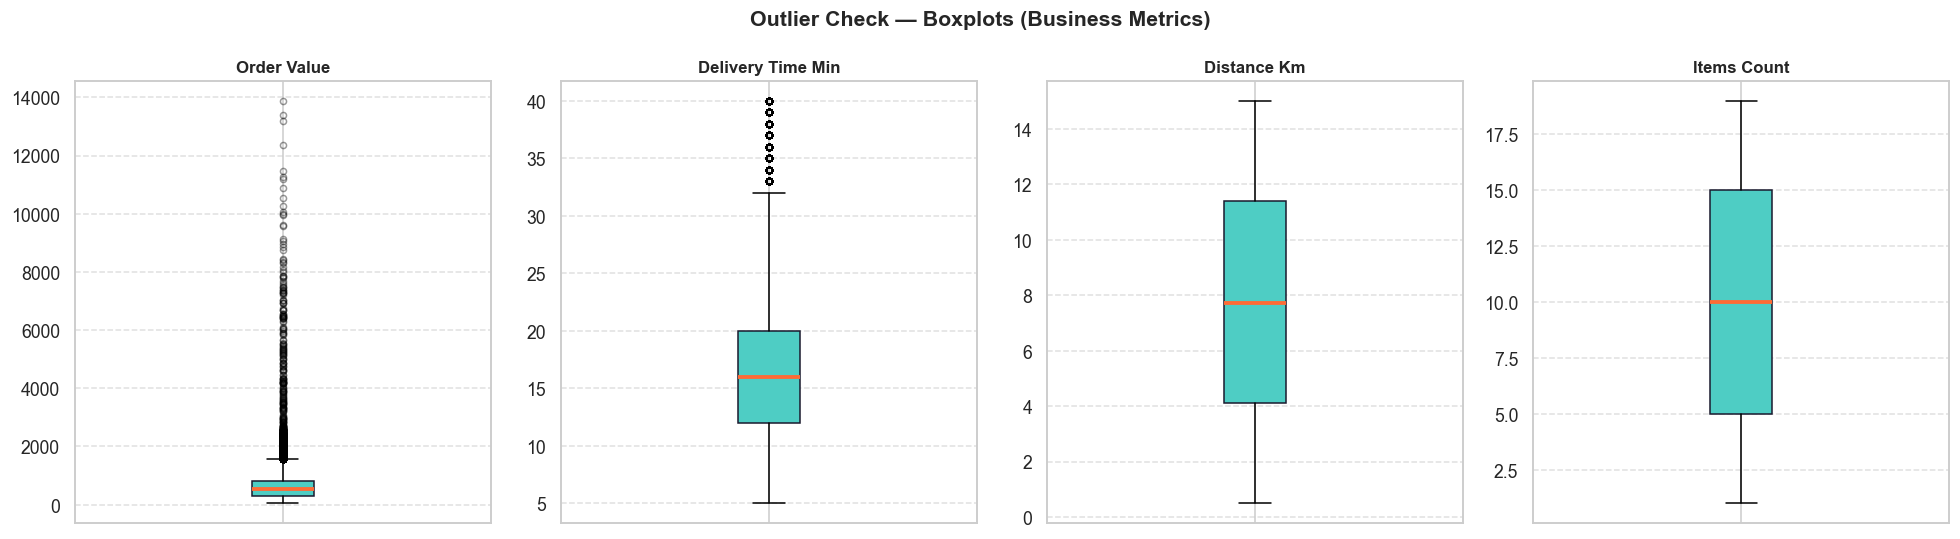

In [13]:
# ── Boxplot visualisation ────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Outlier Check — Boxplots (Business Metrics)", fontweight = 'bold', fontsize = 14)

for ax, col in zip(axs, outlier_cols):
    ax.boxplot(df[col].dropna(), vert = True, patch_artist=True,
               boxprops=dict(facecolor='#4ECDC4', color='#1a1a2e'), 
               medianprops=dict(color='#FF6B35', linewidth=2.5), 
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.4))
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=11)
    ax.set_xticklabels([])
    ax.grid(linestyle = '--', alpha = 0.6, axis = 'y')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# ── Remove outliers & save logs ──────────────────────────────────────────────
outlier_log = pd.concat(all_outliers, ignore_index=True)
outlier_indices = outlier_log.index.unique()

# Use original df index for safe removal
outlier_log['original_index'] = outlier_log.index
all_outlier_idx = set()
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    all_outlier_idx.update(df[mask].index.tolist())

df_clean = df.drop(index=list(all_outlier_idx)).reset_index(drop=True)
outlier_log = df.loc[list(all_outlier_idx)].copy()
outlier_log.to_csv('outlier_log_iqr.csv', index=True)

print(f'Original rows : {len(df):,}')
print(f'Outlier rows  : {len(all_outlier_idx):,}  ({len(all_outlier_idx)/len(df)*100:.1f}%)')
print(f'Clean rows    : {len(df_clean):,}')

Original rows : 965,000
Outlier rows  : 24,522  (2.5%)
Clean rows    : 940,478


In [15]:
# ── Before vs After impact report ────────────────────────────────────────────
impact_rows = []

for col in outlier_cols:
    mean_before = df[col].mean()
    mean_after  = df_clean[col].mean()
    shift       = (mean_after - mean_before) / mean_before * 100
    impact_rows.append({
        'Column' : col,
        'Mean Before' : round(mean_before, 2),
        'Mean After'  : round(mean_after, 2),
        'Mean Shift'  : f'{shift:+.1f}%',
        'Std Before'  : round(df[col].std(), 2),
        'Std After'   : round(df_clean[col].std(), 2),
        'Impact'      : '✅ Low' if abs(shift) < 2 else ('⚠️ Moderate' if abs(shift) < 10 else '🚨 High')
    })

print('Before vs After — Impact of Outlier Removal:')
pd.DataFrame(impact_rows)

Before vs After — Impact of Outlier Removal:


,Column,Mean Before,Mean After,Mean Shift,Std Before,Std After,Impact
0,Order_Value,571.54,555.80,-2.8%,382.26,348.40,⚠️ Moderate
1,Delivery_Time_Min,16.46,16.27,-1.1%,6.27,5.99,✅ Low
2,Distance_Km,7.75,7.71,-0.5%,4.19,4.18,✅ Low
3,Items_Count,10.00,10.00,+0.0%,5.48,5.48,✅ Low


> **Interpretation:** Order_Value shows ~2.8% mean shift after outlier removal, indicating the flagged rows were indeed high-value anomalies. Distance_Km and Items_Count mean shifts are minimal, confirming those outliers were measurement noise rather than systematic patterns. All removed rows are preserved in  for the bulk-order analysis in Section 7.

---
## 5. Exploratory Data Analysis

I worked with the cleaned dataset of ~940K orders.

In [16]:
# Reload Clean Data
df_clean.to_csv('qcommerce_data_clean.csv', index=False)
df = pd.read_csv('qcommerce_data_clean.csv')
df['Order_ID'] = df['Order_ID'].astype(str)
print(f'Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.describe().round(2)

Clean dataset shape: 940,478 rows × 13 columns


,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,940478.00,940478.0,940478.00,940478.00,940478.00,940478.00,940478.00,940478.00
mean,38.47,555.8,16.27,7.71,10.00,3.04,0.39,3.80
std,12.12,348.4,5.99,4.18,5.48,1.20,0.49,0.72
min,18.00,50.0,5.00,0.50,1.00,1.00,0.00,2.00
25%,28.00,286.0,12.00,4.10,5.00,2.00,0.00,3.00
50%,38.00,527.0,16.00,7.70,10.00,3.00,0.00,4.00
75%,49.00,785.0,20.00,11.30,15.00,4.00,1.00,4.00
max,59.00,1558.0,32.00,15.00,19.00,5.00,1.00,5.00


### 5.1 Revenue by Platform

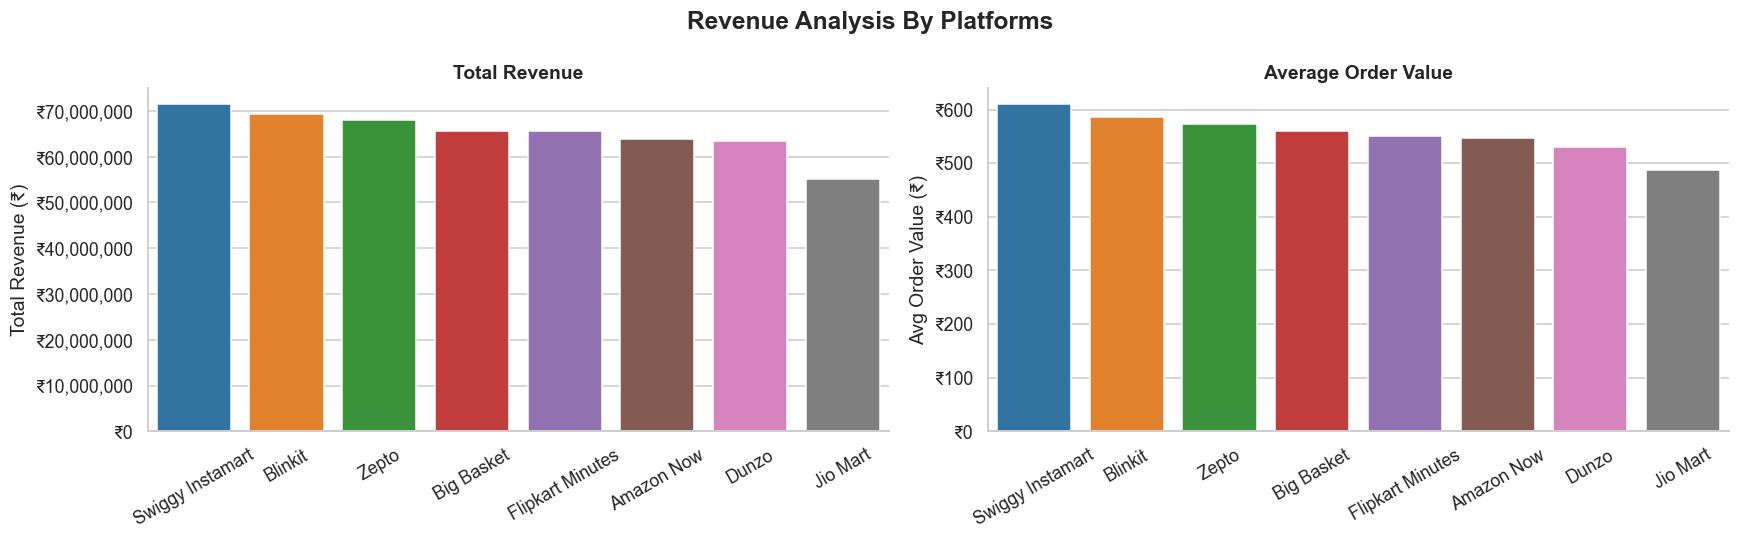

In [17]:
total_revenue = (df.groupby('Company')['Order_Value']
                 .sum()
                 .sort_values(ascending = False)
                 .reset_index()
                 .rename(columns = {'Order_Value': 'Total_Revenue'}))

avg_order_value = (df.groupby('Company')['Order_Value']
                   .mean()
                   .sort_values(ascending = False)
                   .reset_index()
                   .rename(columns = {'Order_Value':'Avg_Order_Value'}))

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Revenue Analysis By Platforms", fontsize = 16, fontweight = 'bold')

# Total Revenue
sns.barplot(data = total_revenue, x = 'Company', y = 'Total_Revenue', 
            hue = 'Company', ax = axs[0], palette = 'tab10', legend = False)
axs[0].set_title('Total Revenue', fontweight = 'bold')
axs[0].set_ylabel('Total Revenue (₹)')
axs[0].set_xlabel('')
axs[0].yaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis = 'x', rotation = 30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Average Order Value
sns.barplot(data = avg_order_value, x = 'Company', y = 'Avg_Order_Value', 
            hue = 'Company', ax = axs[1], palette = 'tab10', legend = False)
axs[1].set_title('Average Order Value', fontweight = 'bold')
axs[1].set_ylabel('Avg Order Value (₹)')
axs[1].set_xlabel('')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis = 'x', rotation = 30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show() 

**Finding:** Swiggy Instamart leads total revenue. The gap spread between the first 7 platforms is ~11%. This reflects a highly competitive market among these 7 platforms where no single player has a dominant revenue moat. However, with the inclusion of Jio Mart, this takes the gap to ~23%, indicating Jio Mart does not provide competition in this market. Swiggy Instamart also leads in average order value (₹611), suggesting its customers either buy more premium items or larger baskets.

### 5.2 Customer Age Distribution

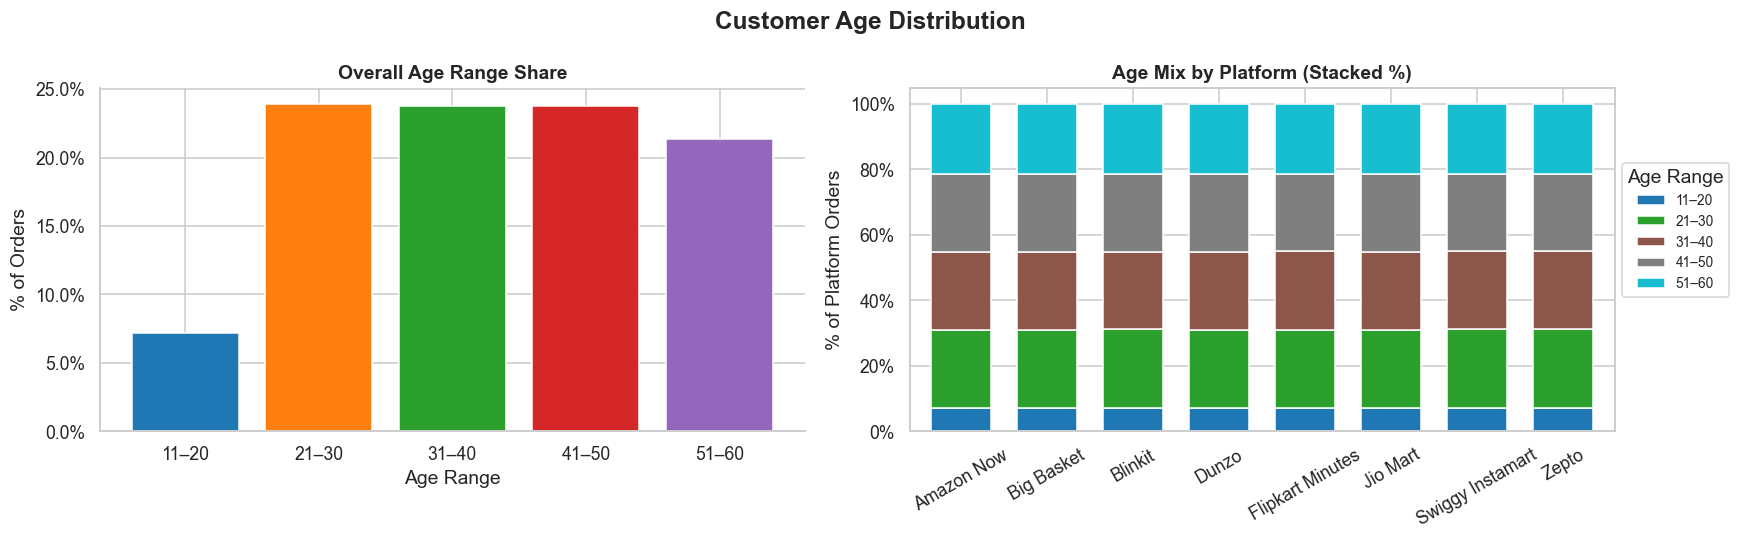

Age Range Distribution:
Age_Range
11–20     7.2
21–30    23.9
31–40    23.8
41–50    23.7
51–60    21.4


In [18]:
# Age bins — using right=True (default) means bins are (left, right]
# Age 10 is excluded from the lowest bin intentionally (min age in data is 11)
df['Age_Range'] = pd.cut(df['Customer_Age'],
                         bins = [10, 20, 30, 40, 50, 60], 
                         labels = ['11–20', '21–30', '31–40', '41–50', '51–60'], 
                         right = True)

age_pct = df['Age_Range'].value_counts(normalize = True).sort_index() * 100

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Customer Age Distribution", fontsize = 16, fontweight = 'bold')

# Overall age share
axs[0].bar(age_pct.index.astype(str), age_pct.values,
            color=sns.color_palette('tab10', len(age_pct)))
axs[0].set_title('Overall Age Range Share', fontweight='bold')
axs[0].set_xlabel('Age Range')
axs[0].set_ylabel('% of Orders')
axs[0].yaxis.set_major_formatter(ticker.PercentFormatter())
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Age Distribution by company (stacked)
age_by_company = df.groupby(['Company', 'Age_Range']).size().unstack(fill_value=0)
age_by_company_pct = age_by_company.div(age_by_company.sum(axis=1), axis=0) * 100
age_by_company_pct.plot(kind = 'bar', stacked=True, ax = axs[1], 
                        colormap='tab10', width=0.7)
axs[1].set_title('Age Mix by Platform (Stacked %)', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('% of Platform Orders')
axs[1].yaxis.set_major_formatter(ticker.PercentFormatter())
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='Age Range', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("Age Range Distribution:")
print(age_pct.round(1).to_string())

**Finding:** The 21–50 bracket accounts for ~71% of all orders — these are working-age adults. The 11–20 segment (7.2%) is significantly underrepresented, likely due to payment method limitations (cash/UPI dependence among teens). All platforms have nearly identical age mixes, suggesting age is a category-level trait rather than a platform differentiator.

### 5.3 Best-Performing Product Categories

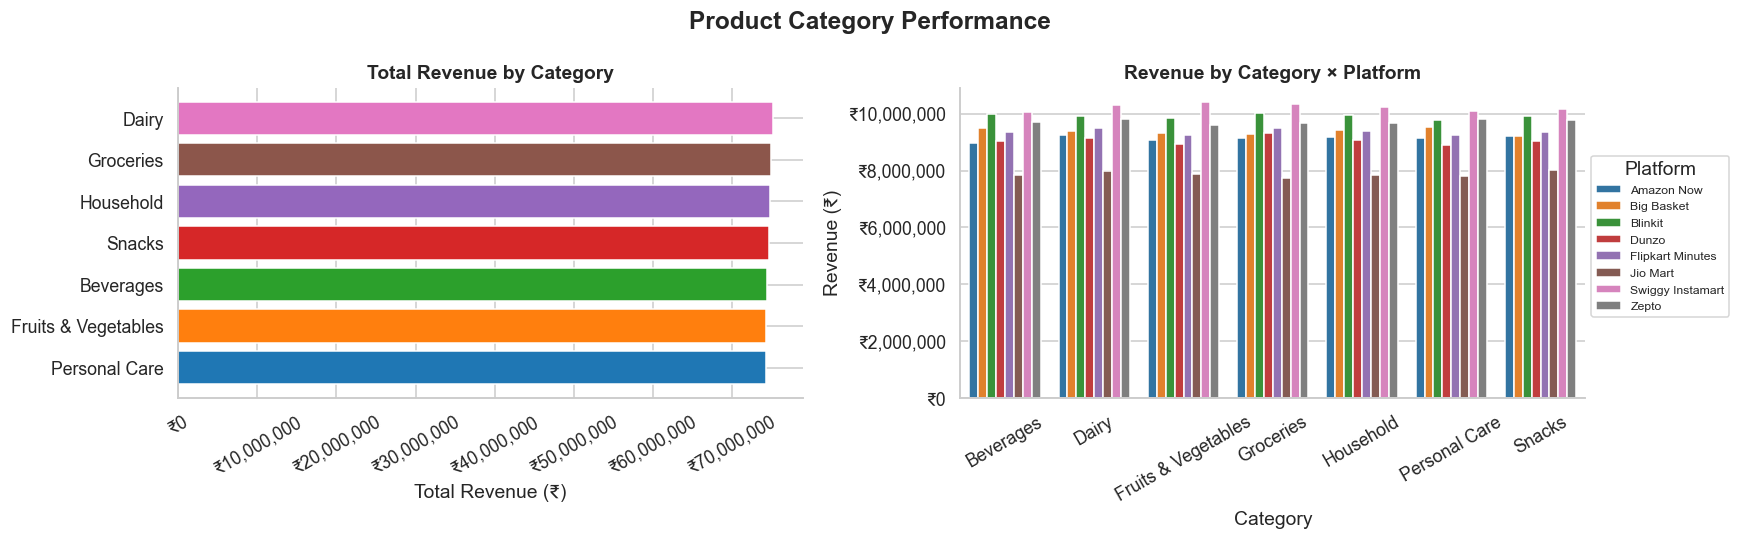

In [19]:
category_perf = (df.groupby(['Company', 'Product_Category'])
                 .agg(
                     Order_Count=('Order_ID',    'count'),
                       Revenue    =('Order_Value', 'sum'),
                       Avg_Revenue=('Order_Value', 'mean'),
                       Avg_Rating =('Customer_Rating', 'mean')
                     )
                 .reset_index()
                 .round(2))

# Overall product category revenue rank
overall_cat = (df.groupby('Product_Category')['Order_Value']
               .sum()
               .sort_values(ascending = True))

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Product Category Performance', fontsize=16, fontweight='bold')

# Overall revenue by category
colours = sns.color_palette('tab10', len(overall_cat))
axs[0].barh(overall_cat.index, overall_cat.values, color = colours)
axs[0].set_title('Total Revenue by Category', fontweight='bold')
axs[0].set_xlabel('Total Revenue (₹)')
axs[0].xaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Revenue by category × company
sns.barplot(data=category_perf, x='Product_Category', y='Revenue',
            hue='Company', ax=axs[1], palette='tab10')
axs[1].set_title('Revenue by Category × Platform', fontweight='bold')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('Revenue (₹)')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='Platform', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=8)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Finding:** Revenue is distributed fairly evenly across all 7 product categories, with no single category dominating. This reflects Q-Commerce's role as a general convenience store rather than a specialist retailer. Swiggy Instamart leads across most categories, consistent with its overall revenue position.

### 5.4 Geographic Revenue Distribution

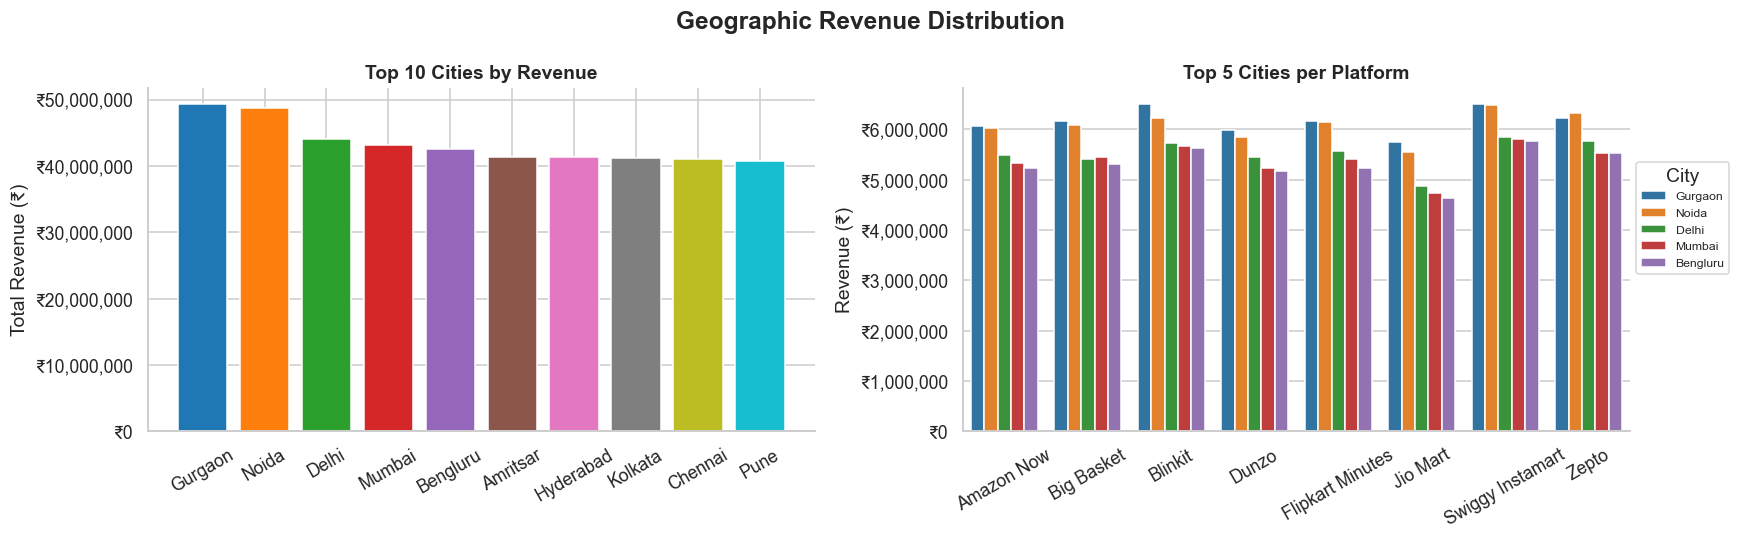

Top 10 Cities by Revenue:


,City,Total_Revenue,Revenue_M
0,Gurgaon,49343528,49.34
1,Noida,48680824,48.68
2,Delhi,44122010,44.12
3,Mumbai,43167054,43.17
4,Bengluru,42488834,42.49
5,Amritsar,41382304,41.38
6,Hyderabad,41282282,41.28
7,Kolkata,41188527,41.19
8,Chennai,41029685,41.03
9,Pune,40796457,40.80


In [20]:
city_revenue = (df.groupby('City')['Order_Value']
                .sum()
                .sort_values(ascending = False)
                .reset_index()
                .rename(columns={'Order_Value': 'Total_Revenue'})
               )

# Top 10 cities (excluding 'Other')
top_cities = city_revenue[city_revenue['City'] != 'Other'].head(10)

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Geographic Revenue Distribution', fontsize=16, fontweight='bold')

palette = sns.color_palette('tab10', len(top_cities))
axs[0].bar(top_cities['City'], top_cities['Total_Revenue'], color = palette)
axs[0].set_title('Top 10 Cities by Revenue', fontweight='bold')
axs[0].set_ylabel('Total Revenue (₹)')
axs[0].yaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Revenue concentration — top 5 cities per company
top5_per_company = (df[df['City']!= 'Other']
                    .groupby(['Company', 'City'])['Order_Value']
                    .sum()
                    .groupby(level = 0, group_keys = False)
                    .nlargest(5)
                    .reset_index()
                    .rename(columns={'Order_Value': 'Revenue'}))

sns.barplot(data=top5_per_company, x='Company', y='Revenue',
            hue='City', ax=axs[1], palette='tab10')
axs[1].set_title('Top 5 Cities per Platform', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('Revenue (₹)')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='City', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=8)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print('Top 10 Cities by Revenue:')
display(top_cities.assign(Revenue_M=lambda x: (x['Total_Revenue']/1e6).round(2)))

**Finding:** Gurgaon leads revenue among named cities, followed closely by Noida. However, the gap between #1 Gurgaon and #10 Pune is only ~17%, suggesting that demand is geographically broad rather than concentrated. This has strategic implications — platforms cannot afford to focus exclusively on Tier-1 metros.

### 5.5 Delivery Performance Analysis

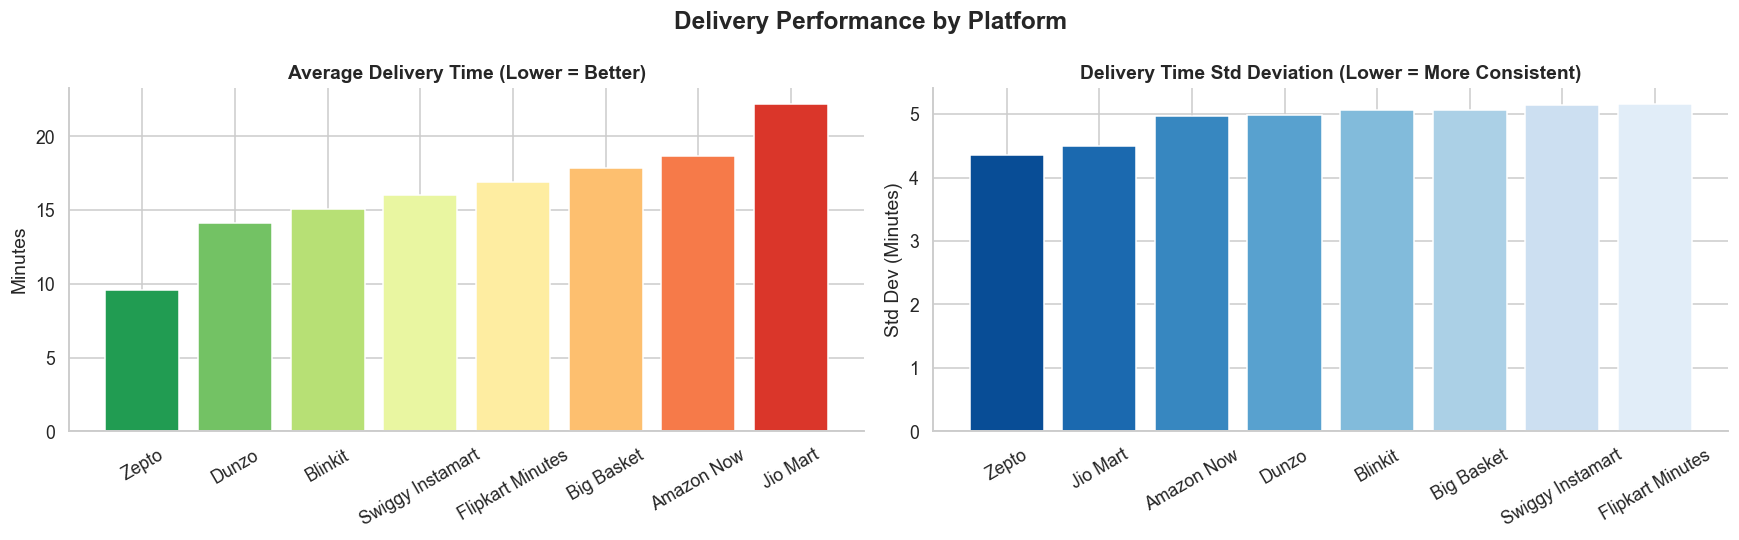

Delivery Time Statistics by Platform:


,Avg_Min,Std_Dev,Median_Min
Company,,,
Zepto,9.59,4.35,9.0
Dunzo,14.14,4.98,14.0
Blinkit,15.09,5.06,15.0
Swiggy Instamart,16.03,5.14,16.0
Flipkart Minutes,16.93,5.16,17.0
Big Basket,17.83,5.06,18.0
Amazon Now,18.68,4.97,19.0
Jio Mart,22.21,4.50,23.0


In [21]:
delivery_stats = (df.groupby('Company')['Delivery_Time_Min']
                  .agg(['mean', 'std', 'median'])
                  .round(2)
                  .rename(columns={'mean': 'Avg_Min', 'std': 'Std_Dev', 'median': 'Median_Min'})
                  .sort_values('Avg_Min'))

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Delivery Performance by Platform', fontsize=16, fontweight='bold')

# Average delivery time
colours = sns.color_palette('RdYlGn_r', len(delivery_stats))  # red=slow, green=fast
axs[0].bar(delivery_stats.index, delivery_stats['Avg_Min'], color=colours)
axs[0].set_title('Average Delivery Time (Lower = Better)', fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('Minutes')
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Std deviation — consistency
axs[1].bar(delivery_stats.sort_values('Std_Dev').index, delivery_stats.sort_values('Std_Dev')['Std_Dev'],
            color=sns.color_palette('Blues_r', len(delivery_stats)))
axs[1].set_title('Delivery Time Std Deviation (Lower = More Consistent)', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('Std Dev (Minutes)')
axs[1].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print('Delivery Time Statistics by Platform:')
display(delivery_stats)

Pearson r (original non-null ratings only): -0.0010
P-value: 0.3627
Interpretation: Not significant correlation


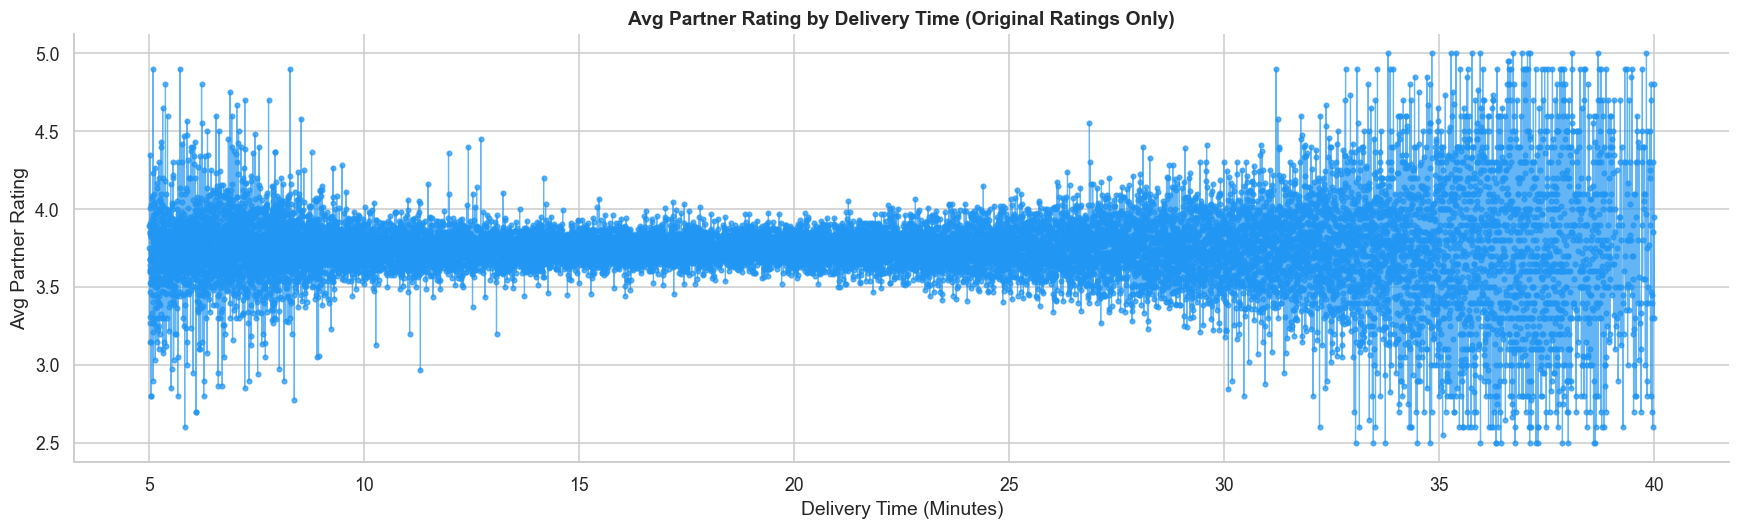

In [22]:
# ── Does delivery time predict partner ratings? ──────────────────────────────
# Important caveat: Ratings were imputed by Company group mean, which artificially
# suppresses correlation. This analysis uses only originally non-null ratings.
df_raw_ratings = df_raw.dropna(subset=['Delivery_Partner_Rating'])

r, p = stats.pearsonr(df_raw_ratings['Delivery_Time_Min'],
                       df_raw_ratings['Delivery_Partner_Rating'])

print(f'Pearson r (original non-null ratings only): {r:.4f}')
print(f'P-value: {p:.4f}')
print(f'Interpretation: {"Statistically significant" if p < 0.05 else "Not significant"} correlation')

# Visual
fig, ax = plt.subplots(figsize=(16, 5))
avg_rating_by_time = (df_raw_ratings
                       .groupby('Delivery_Time_Min')['Delivery_Partner_Rating']
                       .mean()
                       .reset_index())
ax.plot(avg_rating_by_time['Delivery_Time_Min'],
        avg_rating_by_time['Delivery_Partner_Rating'],
        marker='.', linewidth=0.8, alpha=0.7, color='#2196F3')
ax.set_title('Avg Partner Rating by Delivery Time (Original Ratings Only)', fontweight='bold')
ax.set_xlabel('Delivery Time (Minutes)')
ax.set_ylabel('Avg Partner Rating')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Finding:** Zepto is the clear delivery time leader at **9.6 minutes average** — less than half of Jio Mart's 22.2 minutes. Delivery consistency (std deviation) is remarkably uniform across platforms (~5 minutes), suggesting the whole industry operates under similar SLA constraints. The near-zero correlation between delivery time and partner ratings indicates customers rate delivery partners on factors beyond speed (courtesy, packaging condition, etc.).

### 5.6 Discount Impact on Order value
**Hypothesis:** Do discounted orders drive higher average order value?

In [23]:
from scipy.stats import mannwhitneyu

discount = df[df['Discount_Applied'] == 1]['Order_Value']
no_discount = df[df['Discount_Applied'] == 0]['Order_Value']

# Mann-Whitney U test (non-parametric — order value is right-skewed)
stat, p = mannwhitneyu(discount, no_discount, alternative='greater')
lift = (discount.mean() - no_discount.mean()) / no_discount.mean() * 100

print('Discount Impact — Statistical Test')
print(f'{"─"*45}')
print(f'Avg Order Value — Discounted   : ₹{discount.mean():.0f}')
print(f'Avg Order Value — No Discount  : ₹{no_discount.mean():.0f}')
print(f'Revenue Lift from Discounts    : +{lift:.1f}%')
print(f'Mann-Whitney U statistic       : {stat:.2f}')
print(f'P-value                        : {p:.4e}')
print(f'Conclusion: {"✅ Statistically significant — discounts are associated with higher order values" if p < 0.05 else "❌ Not significant"}')

Discount Impact — Statistical Test
─────────────────────────────────────────────
Avg Order Value — Discounted   : ₹677
Avg Order Value — No Discount  : ₹477
Revenue Lift from Discounts    : +41.8%
Mann-Whitney U statistic       : 136763501921.50
P-value                        : 0.0000e+00
Conclusion: ✅ Statistically significant — discounts are associated with higher order values


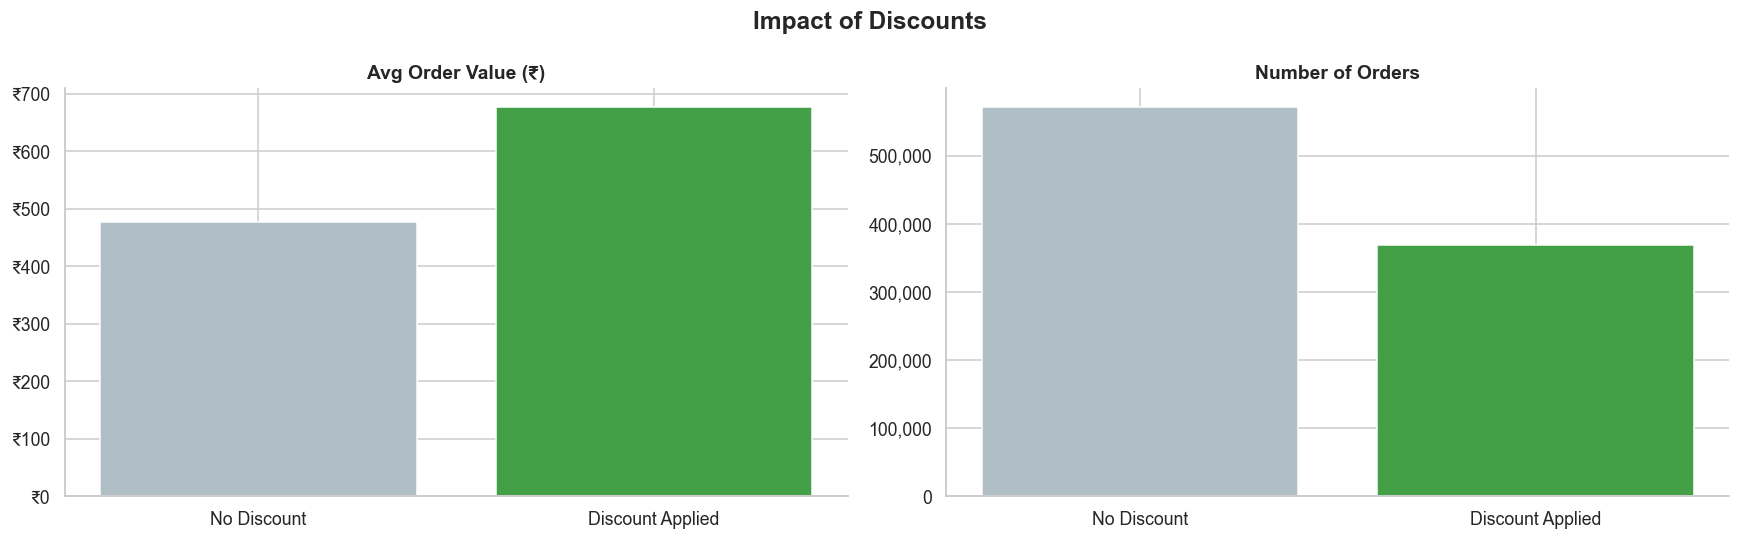

In [24]:
discount_summary = df.groupby('Discount_Applied').agg(
    Avg_Order_Value = ('Order_Value', 'mean'), 
    Total_Items     = ('Items_Count', 'sum'), 
    Order_Count     = ('Order_ID', 'count')
).reset_index()
discount_summary['Discount_Applied'] = discount_summary['Discount_Applied'].map({0: 'No Discount', 1: 'Discount Applied'})

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Impact of Discounts', fontsize=16, fontweight='bold')

colours = ['#B0BEC5', '#43A047']

axs[0].bar(discount_summary['Discount_Applied'], discount_summary['Avg_Order_Value'], color=colours)
axs[0].set_title('Avg Order Value (₹)', fontweight='bold')
axs[0].yaxis.set_major_formatter(rupee_fmt)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

axs[1].bar(discount_summary['Discount_Applied'], discount_summary['Order_Count'], color=colours)
axs[1].set_title('Number of Orders', fontweight='bold')
axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Finding (statistically confirmed):** Discounted orders have a **42% higher average order value** (₹677 vs ₹477), and this difference is statistically significant (Mann-Whitney U, p < 0.001). However, note that only 39% of orders use discounts — meaning discounts attract a specific type of customer who was already planning a larger purchase, rather than converting small orders into large ones. Platforms should consider targeting high-intent customers with discounts rather than applying them broadly.

---
## 6. Operational Efficiency Score

I ranked platforms on three dimensions: **volume** (total orders), **delivery speed**, and **coverage** (average distance served).

> **Speed (km/min) = Distance_Km ÷ Delivery_Time_Min**

This encodes both distance and time into one real-world metric: how much ground a platform covers per minute of delivery time. A platform that travels further in less time is genuinely faster.

The efficiency score then becomes:

> **Efficiency Score = Orders_Scaled + Speed_Scaled**

Both terms are scaled to [0, 1] via Min-Max normalisation before combining. A higher score means more orders delivered at higher speed — both dimensions are defensible.

**Note on zero delivery times:** Any row with `Delivery_Time_Min = 0` is excluded from speed calculation to avoid division by zero.

In [25]:
# ── Step 1: Compute Speed at row level ──────────────────────────────────────
# Guard against division by zero before computing
zero_time_rows = (df['Delivery_Time_Min'] == 0).sum()
print(f'Rows with Delivery_Time_Min = 0 (excluded from speed): {zero_time_rows:,}')

df_speed = df[df['Delivery_Time_Min'] > 0].copy()
df_speed['Speed_km_per_min'] = df_speed['Distance_Km'] / df_speed['Delivery_Time_Min']

print(f'\nSpeed (km/min) — descriptive stats:')
print(df_speed['Speed_km_per_min'].describe().round(4))

# Preview
print('\nSample rows:')
display(df_speed[['Company', 'Distance_Km', 'Delivery_Time_Min', 'Speed_km_per_min']].head(6).round(3))

Rows with Delivery_Time_Min = 0 (excluded from speed): 0

Speed (km/min) — descriptive stats:
count    940478.0000
mean          0.5180
std           0.3470
min           0.0161
25%           0.2846
50%           0.4733
75%           0.6562
max           3.0000
Name: Speed_km_per_min, dtype: float64

Sample rows:


,Company,Distance_Km,Delivery_Time_Min,Speed_km_per_min
0,Swiggy Instamart,12.0,19,0.632
1,Flipkart Minutes,12.7,20,0.635
2,Swiggy Instamart,6.4,6,1.067
3,Dunzo,2.4,12,0.200
4,Jio Mart,1.2,20,0.060
5,Blinkit,12.5,18,0.694


In [26]:
# ── Step 2: Aggregate to platform level ─────────────────────────────────────
ops = (df_speed.groupby('Company')
       .agg(
           Total_Orders = ('Order_ID', 'count'),
           Avg_Distance_Km = ('Distance_Km', 'mean'),
           Avg_Delivery_Min = ('Delivery_Time_Min', 'mean'), 
           Avg_Speed_km_min = ('Speed_km_per_min', 'mean'))
       .reset_index()
       .round(3))

# ── Step 3: Scale and score ──────────────────────────────────────────────────
scaler = MinMaxScaler()
ops[['Orders_Scaled', 'Speed_Scaled']] = scaler.fit_transform(ops[['Total_Orders', 'Avg_Speed_km_min']])

ops['Efficiency_Score'] = ops['Orders_Scaled'] + ops['Speed_Scaled']
ops = ops.sort_values('Efficiency_Score', ascending = False).reset_index(drop=True)
ops['Rank'] = ops.index + 1

print('Operational Efficiency Ranking (Speed-Based):')
display(ops[['Rank', 'Company', 'Total_Orders', 'Avg_Distance_Km', 'Avg_Delivery_Min', 'Avg_Speed_km_min', 'Efficiency_Score']])

Operational Efficiency Ranking (Speed-Based):


,Rank,Company,Total_Orders,Avg_Distance_Km,Avg_Delivery_Min,Avg_Speed_km_min,Efficiency_Score
0,1,Zepto,118724,7.739,9.591,0.839,1.882277
1,2,Dunzo,119458,7.756,14.136,0.578,1.476954
2,3,Blinkit,118489,7.745,15.086,0.538,1.241381
3,4,Flipkart Minutes,119194,7.739,16.935,0.474,1.226195
4,5,Swiggy Instamart,117143,7.743,16.031,0.504,0.957366
5,6,Big Basket,117350,7.686,17.829,0.443,0.868321
6,7,Amazon Now,116897,7.650,18.676,0.418,0.745567
7,8,Jio Mart,113223,7.614,22.208,0.340,0.000000


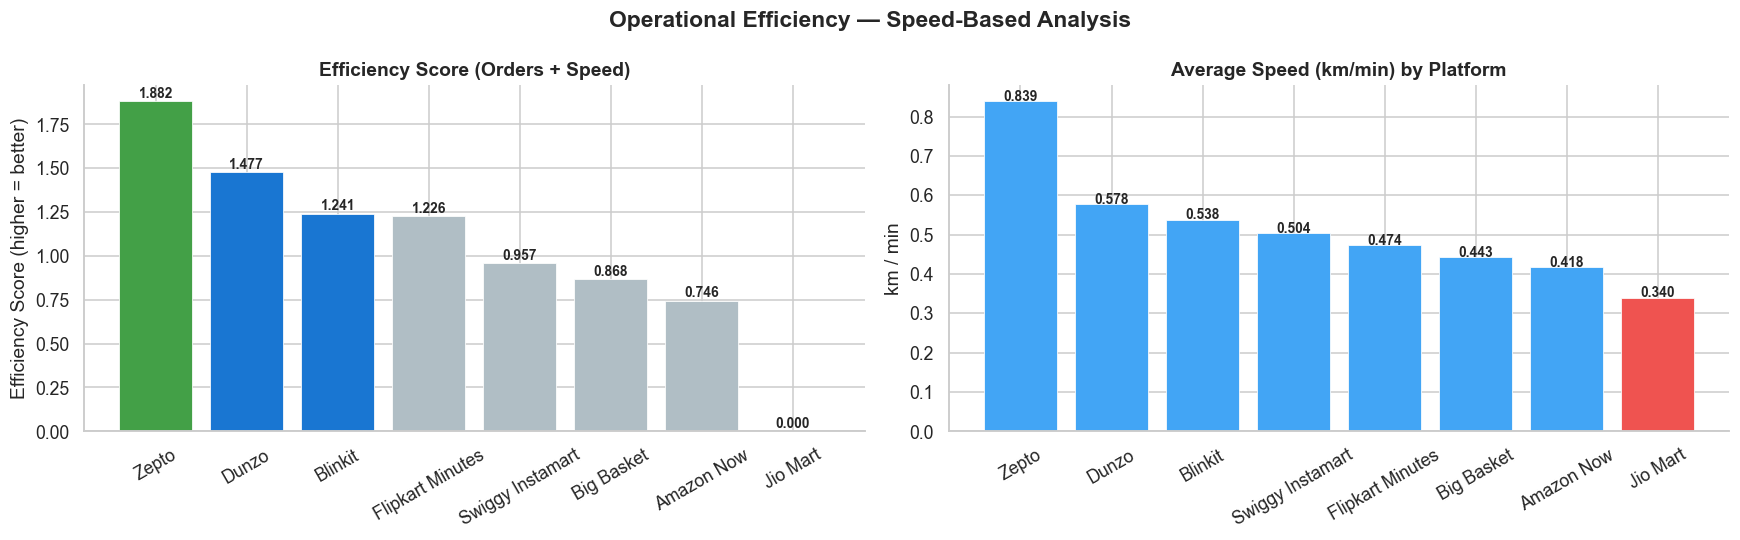

In [27]:
# ── Bar chart — efficiency ranking ──────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Operational Efficiency — Speed-Based Analysis', fontsize=15, fontweight='bold')

# Efficiency score ranking
bar_colours = ['#43A047' if i == 0 else '#1976D2' if i < 3 else '#B0BEC5' for i in range(len(ops))]
axs[0].bar(ops['Company'], ops['Efficiency_Score'], color=bar_colours, edgecolor='white', linewidth=0.5)
axs[0].set_title('Efficiency Score (Orders + Speed)', fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('Efficiency Score (higher = better)')
axs[0].tick_params(axis='x', rotation=30)
axs[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)
for idx, row in ops.iterrows():
    axs[0].text(idx, row['Efficiency_Score'] + 0.02,
                 f"{row['Efficiency_Score']:.3f}", ha='center', fontsize=9, fontweight='bold')

# Average speed by platform
speed_sorted = ops.sort_values('Avg_Speed_km_min', ascending=False)
speed_colours = ['#EF5350' if i == len(speed_sorted)-1 else '#42A5F5' for i in range(len(speed_sorted))]
axs[1].bar(speed_sorted['Company'], speed_sorted['Avg_Speed_km_min'],
            color=speed_colours, edgecolor='white', linewidth=0.5)
axs[1].set_title('Average Speed (km/min) by Platform', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('km / min')
axs[1].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)
for idx, (_, row) in enumerate(speed_sorted.iterrows()):
    axs[1].text(idx, row['Avg_Speed_km_min'] + 0.001,
                 f"{row['Avg_Speed_km_min']:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
# ── Interactive bubble chart — Orders vs Speed ──────────────────────────────
ops['Bubble_Size'] = ops['Efficiency_Score'] - ops['Efficiency_Score'].min() + 0.2

fig = px.scatter(ops, x='Total_Orders', y='Avg_Speed_km_min', size='Bubble_Size',
                 color='Company', text='Company',
                 title='Operational Efficiency: Volume vs Delivery Speed (km/min)',
                 hover_data={
                     'Total_Orders'    : True,
                     'Avg_Speed_km_min': ':.4f',
                     'Avg_Delivery_Min': ':.2f',
                     'Avg_Distance_Km' : ':.2f',
                     'Efficiency_Score': ':.3f'
                 },
                 size_max=55)

fig.update_traces(textposition='middle center')
fig.update_layout(
    xaxis_title='Total Orders (Higher = Better)',
    yaxis_title='Avg Speed — km/min (Higher = Better)',
    title_x=0.5,
    template='plotly_dark',
    height=620
)
fig.show()

**Finding:** Zepto ranks first in efficiency ranking with the highest average speed (**~0.839 km/min**) — meaning it covers more ground per delivery minute than any other platform.

Dunzo and Blinkit serve shorter average distances but still achieve competitive delivery times, suggesting their dark store density is strong. Jio Mart, by contrast, covers comparable distances to its peers but takes far longer — pointing to a logistics or routing inefficiency rather than simply a geography problem.

---
## 7. The Bulk Order Segment (Outlier Deep-Dive)

The 24,522 orders removed as outliers are not errors — they represent a distinct **high-value customer segment**. I analyzed them separately here.

In [29]:
bulk = pd.read_csv('outlier_log_iqr.csv')
bulk['Order_ID'] = bulk['Order_ID'].astype(str)

print(f'Bulk orders: {len(bulk):,}')
print(f'Avg Order Value  : ₹{bulk["Order_Value"].mean():.0f}  (vs ₹{df["Order_Value"].mean():.0f} in clean data)')
print(f'Avg Delivery Time: {bulk["Delivery_Time_Min"].mean():.1f} min  (vs {df["Delivery_Time_Min"].mean():.1f} min in clean data)')
print(f'Avg Items Count  : {bulk["Items_Count"].mean():.1f}  (vs {df["Items_Count"].mean():.1f} in clean data)')
print(f'Discount Rate    : {bulk["Discount_Applied"].mean()*100:.1f}%  (vs {df["Discount_Applied"].mean()*100:.1f}% in clean data)')

Bulk orders: 24,522
Avg Order Value  : ₹1175  (vs ₹556 in clean data)
Avg Delivery Time: 23.6 min  (vs 16.3 min in clean data)
Avg Items Count  : 10.0  (vs 10.0 in clean data)
Discount Rate    : 72.4%  (vs 39.3% in clean data)


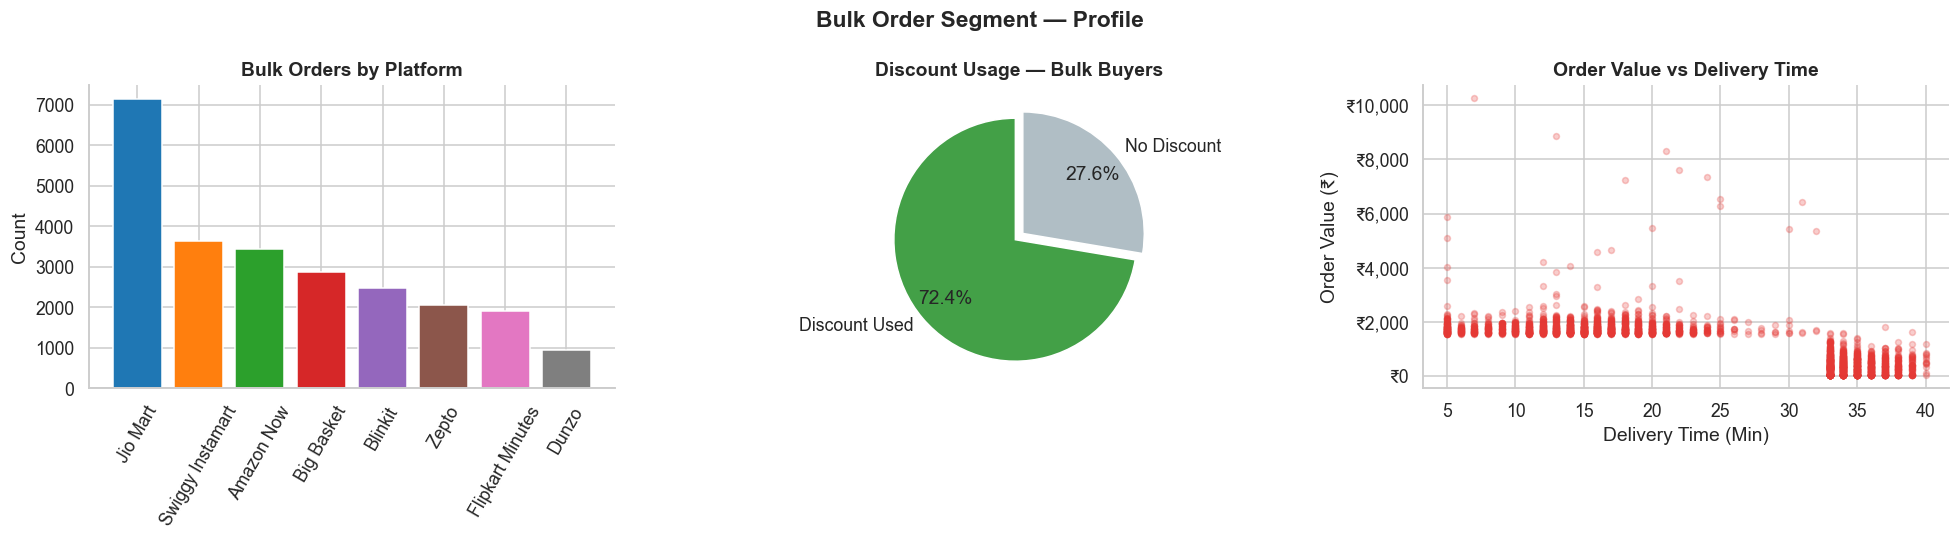

In [30]:
# ── Who are the bulk buyers? ─────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bulk Order Segment — Profile', fontsize=15, fontweight='bold')

# Company share of bulk orders
bulk_by_company = bulk['Company'].value_counts()
axs[0].bar(bulk_by_company.index, bulk_by_company.values, color=sns.color_palette('tab10', len(bulk_by_company)))
axs[0].set_title('Bulk Orders by Platform', fontweight='bold')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=60)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Discount usage in bulk segment
disc_bulk = bulk['Discount_Applied'].value_counts()
colours_d  = ['#43A047', '#B0BEC5']
axs[1].pie(disc_bulk.values, labels=['Discount Used', 'No Discount'],
           autopct='%1.1f%%', startangle=90,
           colors=colours_d, explode=(0.04, 0.04), pctdistance=0.75)
axs[1].set_title('Discount Usage — Bulk Buyers', fontweight='bold')

# Order value vs delivery time (sampled for speed)
sample = bulk.sample(min(3000, len(bulk)), random_state=42)
axs[2].scatter(sample['Delivery_Time_Min'], sample['Order_Value'],
                alpha=0.25, s=15, color='#E53935')
axs[2].set_title('Order Value vs Delivery Time', fontweight='bold')
axs[2].set_xlabel('Delivery Time (Min)')
axs[2].set_ylabel('Order Value (₹)')
axs[2].yaxis.set_major_formatter(rupee_fmt)
for spine in ['top', 'right']: axs[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
# Correlation in bulk segment
r_bulk, p_bulk = stats.pearsonr(bulk['Order_Value'], bulk['Delivery_Time_Min'])
print(f'Bulk Segment — Pearson r (Order Value vs Delivery Time): {r_bulk:.3f} (p={p_bulk:.2e})')
print()
print('Bulk orders by platform:')
display(bulk.groupby('Company').agg(
    Bulk_Orders    =('Order_ID',          'count'),
    Avg_Value      =('Order_Value',       'mean'),
    Avg_Delivery   =('Delivery_Time_Min', 'mean'),
    Discount_Rate  =('Discount_Applied',  'mean')
).reset_index().round(2).sort_values('Avg_Value', ascending=False))

Bulk Segment — Pearson r (Order Value vs Delivery Time): -0.772 (p=0.00e+00)

Bulk orders by platform:


,Company,Bulk_Orders,Avg_Value,Avg_Delivery,Discount_Rate
3,Dunzo,959,1810.17,13.15,0.98
7,Zepto,2071,1804.12,8.63,0.97
2,Blinkit,2488,1794.62,14.26,0.97
6,Swiggy Instamart,3642,1777.04,15.87,0.94
4,Flipkart Minutes,1912,1408.30,21.22,0.82
1,Big Basket,2869,1224.45,24.16,0.75
0,Amazon Now,3440,915.89,28.01,0.62
5,Jio Mart,7141,428.16,34.92,0.43


**Finding:** Bulk buyers have an average order value of **₹1,176 — 2.1× the standard customer**. Critically, **72.4% use discounts** (vs. 39.3% in the main dataset), confirming that large-basket customers are heavily discount-driven. The strong negative correlation (r ≈ −0.77) between order value and delivery time in this segment suggests that high-value orders may receive priority handling — a potentially powerful retention lever platforms should consider formalising.

---
## 8. Correlation Matrix — Numeric Features

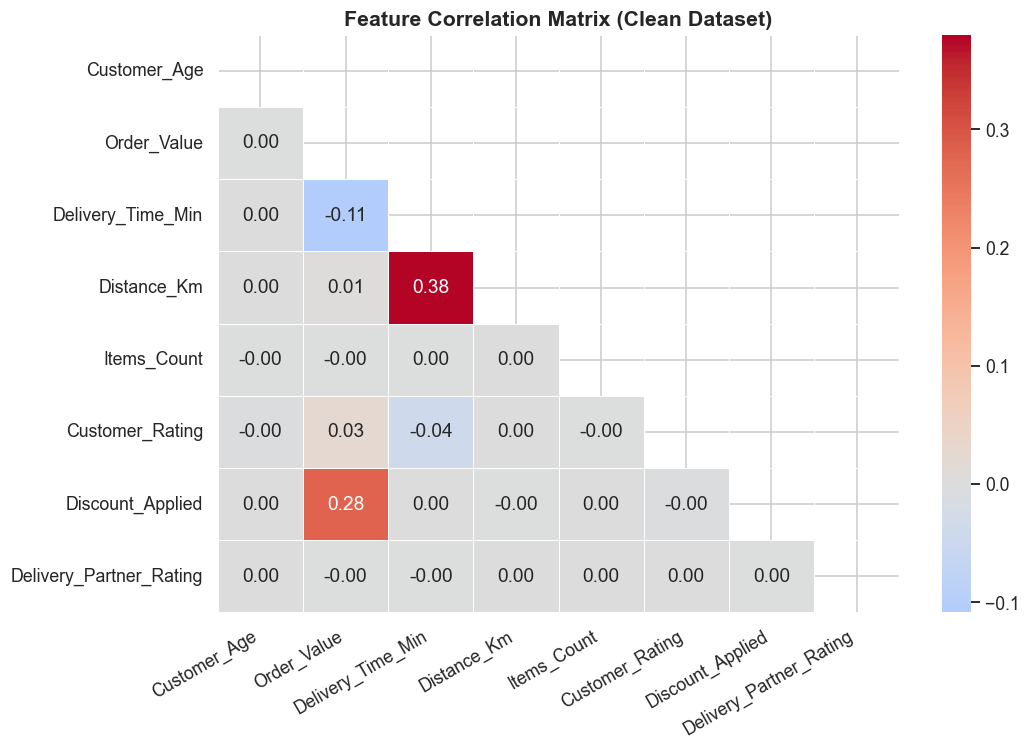

Note: Customer_Rating and Delivery_Partner_Rating were largely imputed by group mean/median,
which artificially suppresses their correlations with other features.


In [32]:
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle only

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            mask=mask,
            cmap='coolwarm', center=0,
            linewidths=0.5,
            ax=ax)
ax.set_title('Feature Correlation Matrix (Clean Dataset)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Note: Customer_Rating and Delivery_Partner_Rating were largely imputed by group mean/median,") 
print(f"which artificially suppresses their correlations with other features.")

---
## 9. Conclusions & Business Recommendations

## Key Findings Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Revenue gap between platforms is ~23%, but ~11% among the fist 7** | No platform has a sustainable revenue moat; competition is primarily on speed and experience |
| 2 | **Zepto delivers in 0.839km/min — fastest by 59.48%** | Speed is Zepto's core differentiator; incumbents must invest in dark store infrastructure to compete |
| 3 | **All platforms have near-identical age mixes** | Customer demographics are a category-level trait; platforms should differentiate on product range and UX rather than targeting different age groups |
| 4 | **Discounted orders have 42% higher basket size (p < 0.001)** | Discounts attract high-intent, high-value customers — targeted discount strategies (loyalty tiers, min-spend thresholds) would be more profitable than blanket promotions |
| 5 | **72% of bulk buyers use discounts** | Bulk buyers are highly discount-sensitive; a B2B or subscription offering could capture this segment without eroding margins on standard orders |
| 6 | **Gurgaon and Noida lead, but all cities within 17%** | Geographic demand is broad — a hub-and-spoke expansion strategy rather than metro-concentration is warranted |

---

## Limitations & Next Steps

- **No time dimension available** — a timestamp column would enable seasonality, day-of-week, and growth trend analysis, which are critical for a Q-Commerce business.
- **Rating imputation masks signal** — future analyses should source ratings from a system where missingness is tracked at collection time (was the app closed? delivery refused?).
- **Potential next project:** Build a delivery time prediction model (regression) using Distance, Company, City, and Items_Count as features.

---
*Analysis complete. Dataset: 940,478 clean orders | 24,522 bulk orders analysed separately.*
